<a href="https://www.kaggle.com/code/lalit7881/funnel-retention-prediction-eda?scriptVersionId=314208628" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt 
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/mdmahfuzsumon/funnel-synthetic-dataset-customer-retention-model/train.parquet
/kaggle/input/datasets/mdmahfuzsumon/funnel-synthetic-dataset-customer-retention-model/test.parquet


## Loading dataset

In [2]:
# File paths
train_path = "/kaggle/input/datasets/mdmahfuzsumon/funnel-synthetic-dataset-customer-retention-model/train.parquet"
test_path = "/kaggle/input/datasets/mdmahfuzsumon/funnel-synthetic-dataset-customer-retention-model/test.parquet"

# Read parquet files
train_df = pd.read_parquet(train_path)
test_df = pd.read_parquet(test_path)

# Basic info
print("Train Shape:", train_df.shape)
print("Test Shape:", test_df.shape)

# Preview data
print("\nTrain Head:")
print(train_df.head())

print("\nTest Head:")
print(test_df.head())

# Column info
print("\nTrain Info:")
print(train_df.info())

print("\nTest Info:")
print(test_df.info())

# Check missing values
print("\nMissing Values (Train):")
print(train_df.isnull().sum())

print("\nMissing Values (Test):")
print(test_df.isnull().sum())

# Summary statistics
print("\nTrain Describe:")
print(train_df.describe(include='all'))

print("\nTest Describe:")
print(test_df.describe(include='all'))

Train Shape: (299665, 24)
Test Shape: (74916, 23)

Train Head:
        company_id customer_id  country  year  product_id  product_price  \
80519           22      C22_50    Japan  2021          29         298.25   
282444          76      C76_50  Germany  2011          32          89.41   
10338            3       C3_76    India  2023          62         139.32   
92505           25      C25_70    China  2019          78          41.65   
189862          51      C51_77      USA  2022          20         149.16   

       product_category  awareness_score  engagement_score  subscription  ...  \
80519       Electronics               47              71.1             0  ...   
282444      Electronics               53              49.9             1  ...   
10338              Home               93              90.9             0  ...   
92505           Grocery               82              61.6             0  ...   
189862             Home               36              58.8             1  .

In [3]:
print("Columns:\n", train_df.columns.tolist())

# Separate column types
num_cols = train_df.select_dtypes(include=['int64','float64']).columns
cat_cols = train_df.select_dtypes(include=['object','category']).columns

print("Numerical Columns:", num_cols)
print("Categorical Columns:", cat_cols)

Columns:
 ['company_id', 'customer_id', 'country', 'year', 'product_id', 'product_price', 'product_category', 'awareness_score', 'engagement_score', 'subscription', 'purchase_count', 'avg_order_value', 'support_response_time', 'referral_count', 'focus_score', 'niche_fit', 'differentiation_score', 'value_score', 'barrier_score', 'consistency_score', 'leverage_score', 'satisfaction_score', 'repeat_purchase', 'retention']
Numerical Columns: Index(['company_id', 'year', 'product_id', 'product_price', 'awareness_score',
       'engagement_score', 'subscription', 'purchase_count', 'avg_order_value',
       'support_response_time', 'referral_count', 'focus_score', 'niche_fit',
       'differentiation_score', 'value_score', 'barrier_score',
       'consistency_score', 'leverage_score', 'satisfaction_score',
       'repeat_purchase', 'retention'],
      dtype='object')
Categorical Columns: Index(['customer_id', 'country', 'product_category'], dtype='object')


## EDA

Combined Shape: (374581, 24)


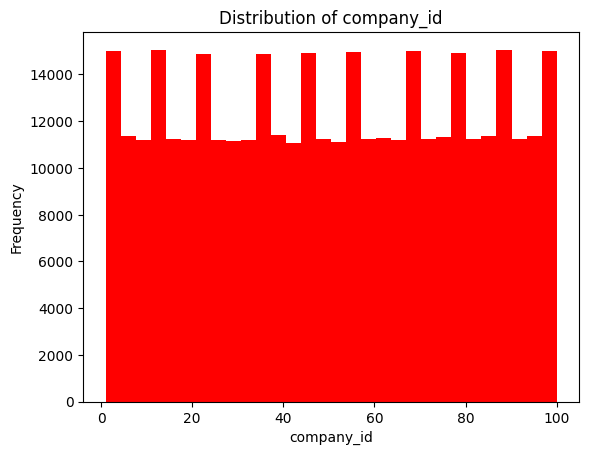

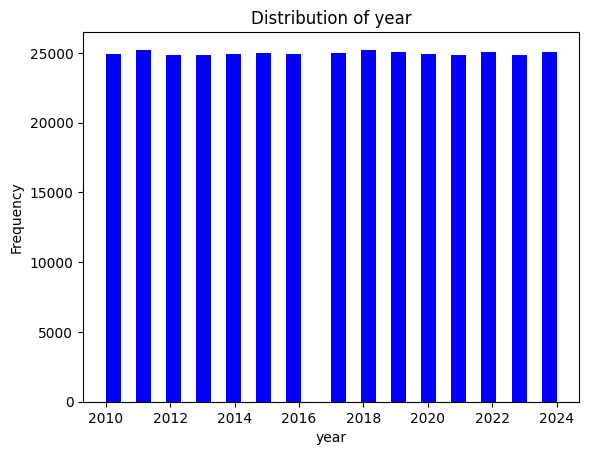

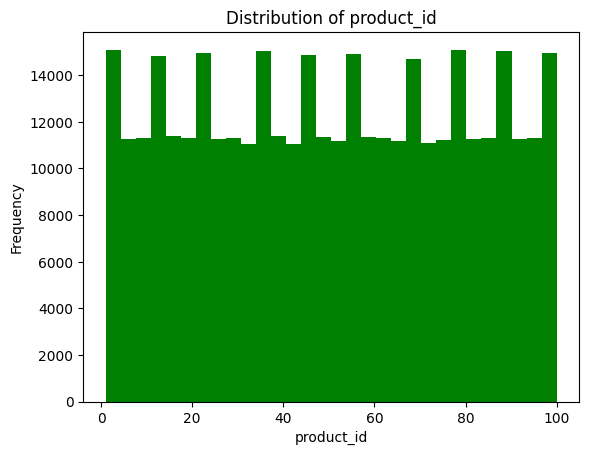

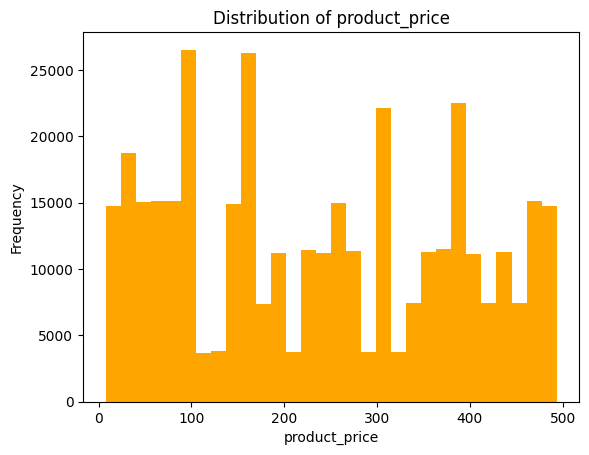

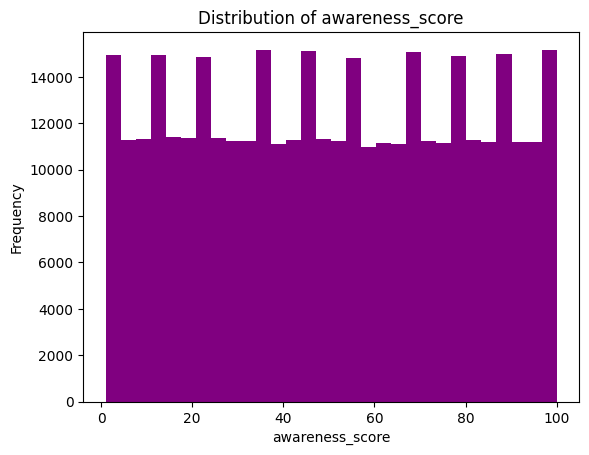

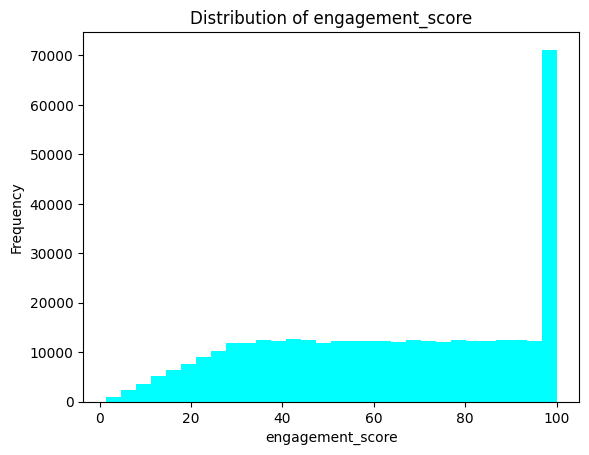

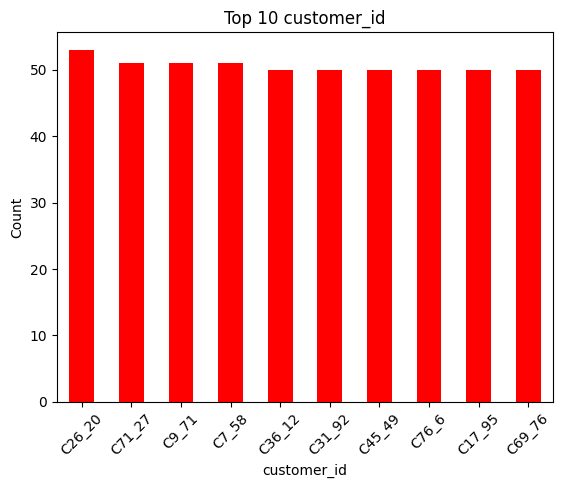

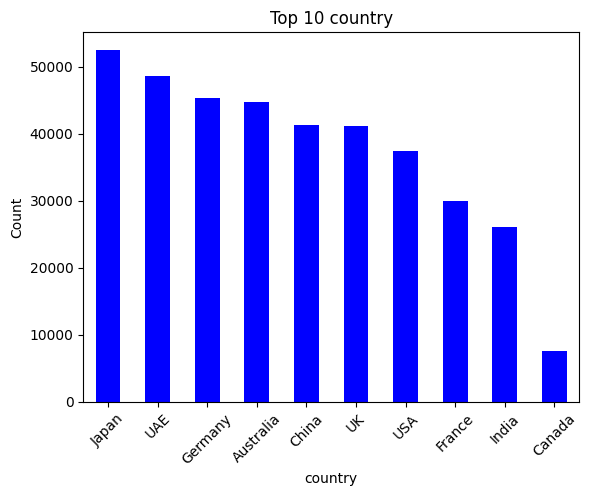

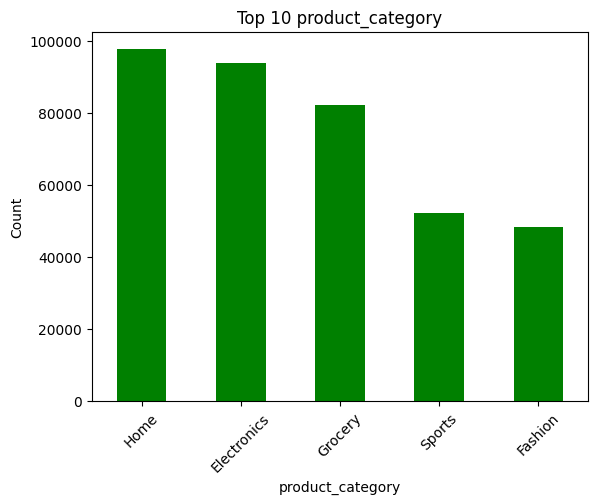

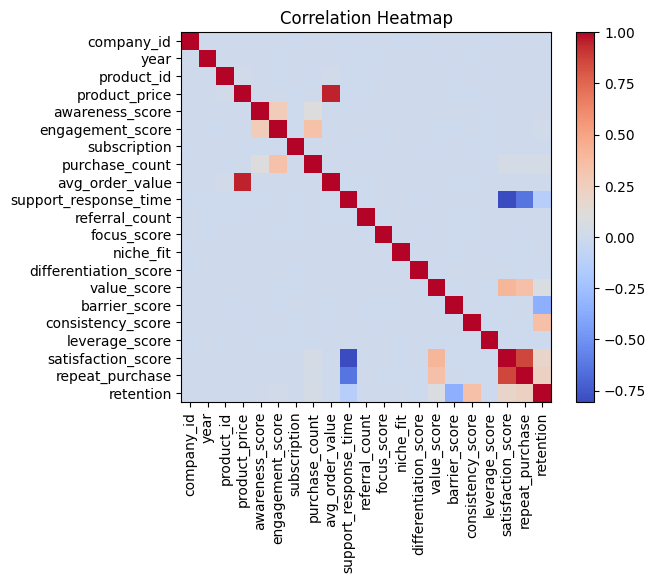

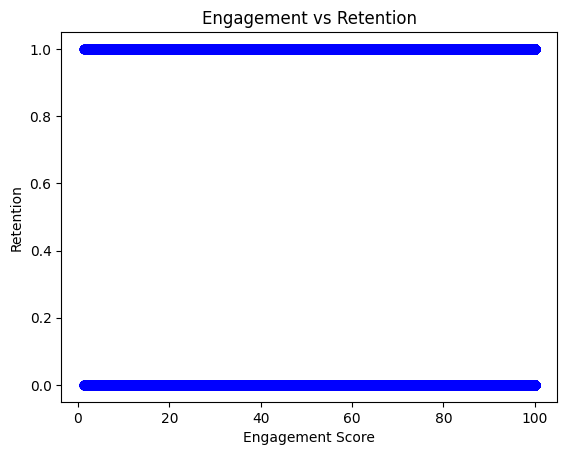

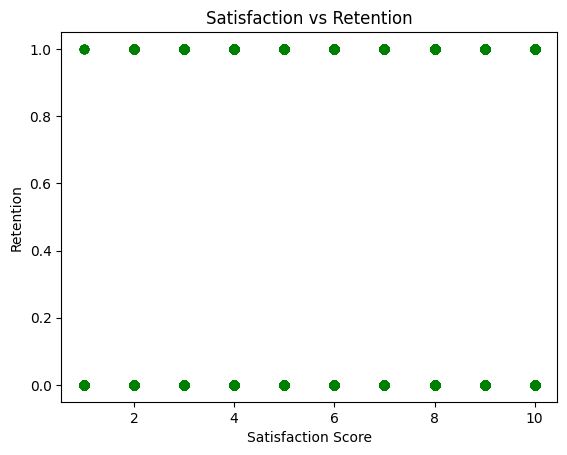

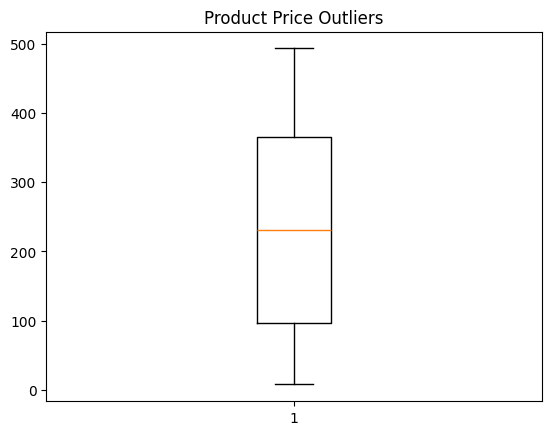

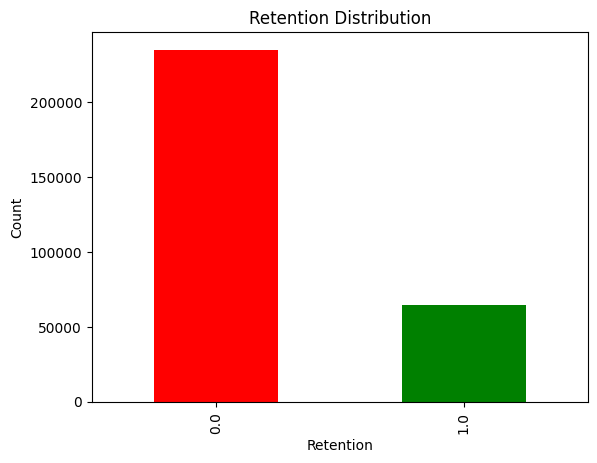

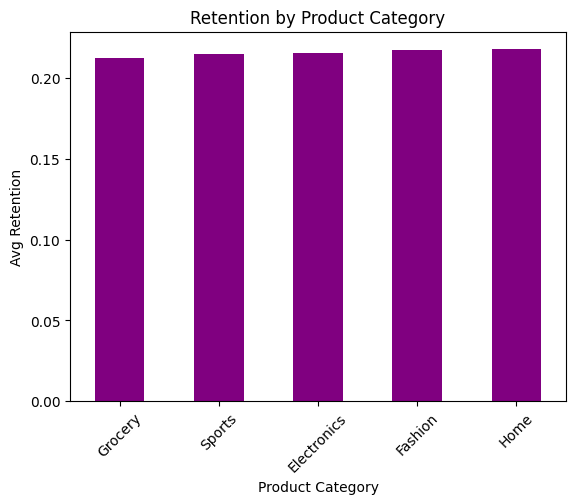

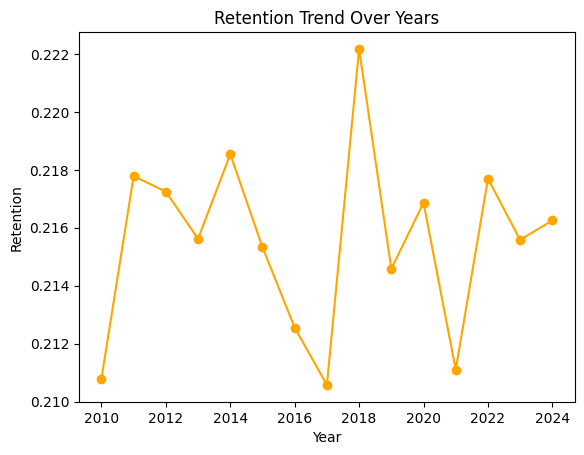

In [4]:
train_df = pd.read_parquet(train_path)
test_df = pd.read_parquet(test_path)

# Combine for visualization only (NO leakage issue here since no modeling)
df = pd.concat([train_df, test_df], axis=0)

print("Combined Shape:", df.shape)

# -------------------------------
# 2. Column Groups
# -------------------------------
num_cols = ['company_id', 'year', 'product_id', 'product_price', 'awareness_score',
       'engagement_score', 'subscription', 'purchase_count', 'avg_order_value',
       'support_response_time', 'referral_count', 'focus_score', 'niche_fit',
       'differentiation_score', 'value_score', 'barrier_score',
       'consistency_score', 'leverage_score', 'satisfaction_score',
       'repeat_purchase', 'retention']

cat_cols = ['customer_id', 'country', 'product_category']

# -------------------------------
# 3. Histograms (Numerical)
# -------------------------------
colors = ['red','blue','green','orange','purple','cyan']

for i, col in enumerate(num_cols[:6]):
    plt.figure()
    plt.hist(df[col], bins=30, color=colors[i])
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

# -------------------------------
# 4. Categorical Count Plots
# -------------------------------
for i, col in enumerate(cat_cols):
    plt.figure()
    df[col].value_counts().head(10).plot(kind='bar', color=colors[i])
    plt.title(f'Top 10 {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45)
    plt.show()

# -------------------------------
# 5. Correlation Heatmap
# -------------------------------
plt.figure()
corr = df[num_cols].corr()

plt.imshow(corr, cmap='coolwarm')
plt.colorbar()
plt.xticks(range(len(num_cols)), num_cols, rotation=90)
plt.yticks(range(len(num_cols)), num_cols)
plt.title("Correlation Heatmap")
plt.show()

# -------------------------------
# 6. Key Relationships
# -------------------------------
plt.figure()
plt.scatter(df['engagement_score'], df['retention'], color='blue')
plt.xlabel('Engagement Score')
plt.ylabel('Retention')
plt.title('Engagement vs Retention')
plt.show()

plt.figure()
plt.scatter(df['satisfaction_score'], df['retention'], color='green')
plt.xlabel('Satisfaction Score')
plt.ylabel('Retention')
plt.title('Satisfaction vs Retention')
plt.show()

# -------------------------------
# 7. Boxplot (Outliers)
# -------------------------------
plt.figure()
plt.boxplot(df['product_price'])
plt.title('Product Price Outliers')
plt.show()

# -------------------------------
# 8. Retention Distribution
# -------------------------------
plt.figure()
df['retention'].value_counts().plot(kind='bar', color=['red','green'])
plt.title('Retention Distribution')
plt.xlabel('Retention')
plt.ylabel('Count')
plt.show()

# -------------------------------
# 9. Category vs Retention
# -------------------------------
cat_ret = df.groupby('product_category')['retention'].mean().sort_values()

plt.figure()
cat_ret.plot(kind='bar', color='purple')
plt.title('Retention by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Avg Retention')
plt.xticks(rotation=45)
plt.show()

# -------------------------------
# 10. Year Trend
# -------------------------------
year_trend = df.groupby('year')['retention'].mean()

plt.figure()
plt.plot(year_trend.index, year_trend.values, marker='o', color='orange')
plt.title('Retention Trend Over Years')
plt.xlabel('Year')
plt.ylabel('Retention')
plt.show()

## Feature engineering


===== Logistic Regression =====
Accuracy: 0.8922963976440358
Confusion Matrix:
 [[45364  1652]
 [ 4803  8114]]


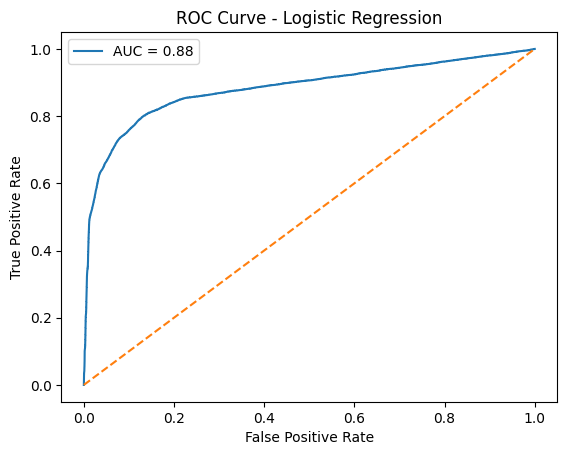


===== Random Forest =====
Accuracy: 0.9506949426859994
Confusion Matrix:
 [[46470   546]
 [ 2409 10508]]


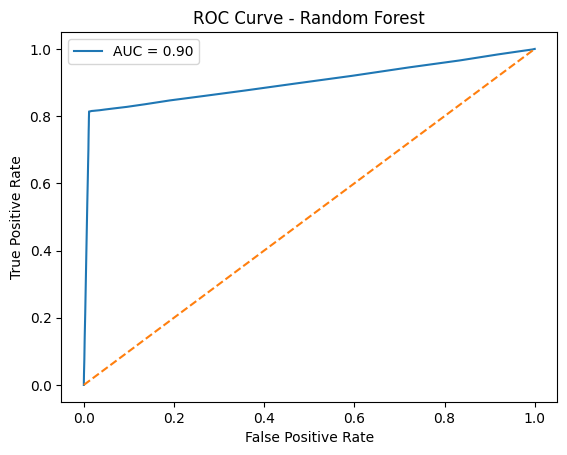


===== Decision Tree =====
Accuracy: 0.8899437705437738
Confusion Matrix:
 [[43416  3600]
 [ 2996  9921]]


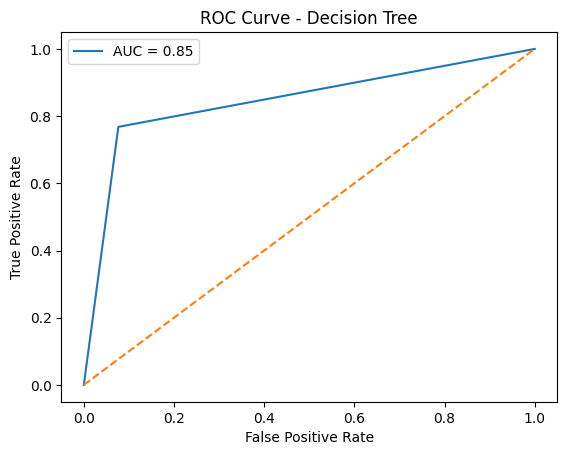


Test data ready for prediction ✅


In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier


# -------------------------------
# 2. Define Target
# -------------------------------
target_col = "retention"

# -------------------------------
# 3. Separate Features & Target
# -------------------------------
X = train_df.drop(columns=[target_col])
y = train_df[target_col]

# -------------------------------
# 4. Column Types
# -------------------------------
num_cols = X.select_dtypes(include=['int64','float64']).columns
cat_cols = X.select_dtypes(include=['object','category']).columns

# -------------------------------
# 5. Handle Missing Values (TRAIN ONLY)
# -------------------------------
for col in num_cols:
    X[col] = X[col].fillna(X[col].median())

for col in cat_cols:
    X[col] = X[col].fillna(X[col].mode()[0])

# -------------------------------
# 6. Label Encoding (FIT ONLY ON TRAIN)
# -------------------------------
label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    label_encoders[col] = le

# -------------------------------
# 7. Train-Test Split
# -------------------------------
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# -------------------------------
# 8. Feature Scaling (ONLY NUMERIC)
# -------------------------------
scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_val[num_cols] = scaler.transform(X_val[num_cols])

# -------------------------------
# 9. Models
# -------------------------------
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42)
}

# -------------------------------
# 10. Training + Evaluation
# -------------------------------
for name, model in models.items():
    print(f"\n===== {name} =====")
    
    # Train
    model.fit(X_train, y_train)
    
    # Predictions
    y_pred = model.predict(X_val)
    y_prob = model.predict_proba(X_val)[:, 1]
    
    # Accuracy
    acc = accuracy_score(y_val, y_pred)
    print("Accuracy:", acc)
    
    # Confusion Matrix
    cm = confusion_matrix(y_val, y_pred)
    print("Confusion Matrix:\n", cm)
    
    # -------------------------------
    # ROC Curve
    # -------------------------------
    fpr, tpr, _ = roc_curve(y_val, y_prob)
    roc_auc = auc(fpr, tpr)
    
    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
    plt.plot([0,1], [0,1], linestyle='--')
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve - {name}")
    plt.legend()
    plt.show()

# -------------------------------
# 11. Apply SAME Processing on TEST
# -------------------------------
X_test = test_df.copy()

# Missing values (use TRAIN stats)
for col in num_cols:
    X_test[col] = X_test[col].fillna(X[col].median())

for col in cat_cols:
    X_test[col] = X_test[col].fillna(X[col].mode()[0])

# Encoding (use SAME encoders)
for col in cat_cols:
    le = label_encoders[col]
    X_test[col] = le.transform(X_test[col])

# Scaling
X_test[num_cols] = scaler.transform(X_test[num_cols])

print("\nTest data ready for prediction ✅")

## Thank you..pls upvote!!!!!!!!